In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
plt.rcParams["figure.figsize"] = [10,5]
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [5]:
full_data = pd.read_csv("titanic_dataset.csv")

In [7]:
full_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
full_data.shape

(891, 12)

In [9]:
import sklearn

In [10]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


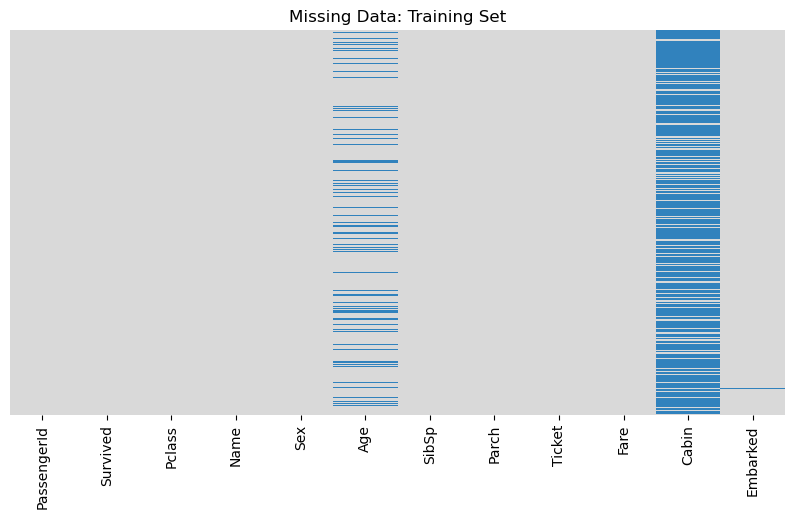

In [11]:
sns.heatmap(full_data.isnull(), yticklabels = False, cbar = False, cmap = "tab20c_r")
plt.title("Missing Data: Training Set")
plt.show()

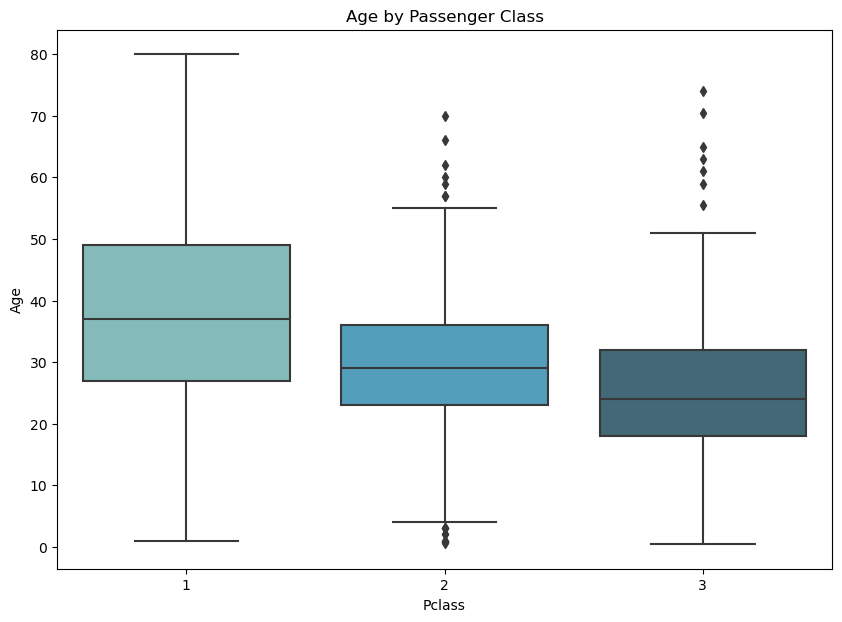

In [13]:
plt.figure(figsize = (10,7))
sns.boxplot(x="Pclass", y="Age", data=full_data, palette = "GnBu_d").set_title('Age by Passenger Class')
plt.show()

In [14]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age
full_data['Age'] = full_data[['Age', 'Pclass']].apply(impute_age, axis = 1)

In [17]:
full_data.drop('Cabin', inplace = True, axis = 1)

In [18]:
full_data.dropna(inplace = True)

In [19]:
full_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [26]:
full_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,24.0,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [27]:
full_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.019314,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,13.209814,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,36.500000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
full_data.drop('PassengerId', axis = 1, inplace = True)

In [29]:
full_data.shape

(889, 8)

In [31]:
objcat = ['Sex','Embarked']

for colname in objcat:
    full_data[colname] = full_data[colname].astype('category')

In [32]:
full_data.select_dtypes(['category']).columns

Index(['Sex', 'Embarked'], dtype='object')

In [33]:
full_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,24.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [34]:
sex = pd.get_dummies(full_data['Sex'], drop_first = True)

In [35]:
embarked = pd.get_dummies(full_data['Embarked'], drop_first = True)

In [36]:
full_data = pd.concat([full_data, sex, embarked], axis = 1)

In [37]:
full_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,0,3,male,22.0,1,0,7.2500,S,True,False,True
1,1,1,female,38.0,1,0,71.2833,C,False,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,True,False,True


In [38]:
full_data.drop(['Sex', 'Embarked'], axis = 1, inplace = True)

In [39]:
full_data.shape
full_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [40]:
x = full_data.drop('Survived', axis = 1)

In [41]:
y = full_data['Survived']

In [42]:
x.shape

(889, 8)

In [43]:
y.shape

(889,)

In [46]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = .20, random_state = 101)

In [48]:
x_train.shape
x_train

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
307,1,17.0,1,0,108.9000,False,False,False
229,3,24.0,3,1,25.4667,False,False,True
82,3,24.0,0,0,7.7875,False,True,False
353,3,25.0,1,0,17.8000,True,False,True
707,1,42.0,0,0,26.2875,True,False,True
...,...,...,...,...,...,...,...,...
576,2,34.0,0,0,13.0000,False,False,True
840,3,20.0,0,0,7.9250,True,False,True
338,3,45.0,0,0,8.0500,True,False,True
524,3,24.0,0,0,7.2292,True,False,False


In [49]:
x_test.shape
x_test

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
511,3,24.0,0,0,8.0500,True,False,True
613,3,24.0,0,0,7.7500,True,True,False
615,2,24.0,1,2,65.0000,False,False,True
337,1,41.0,0,0,134.5000,False,False,False
718,3,24.0,0,0,15.5000,True,True,False
...,...,...,...,...,...,...,...,...
155,1,51.0,0,1,61.3792,True,False,False
450,2,36.0,1,2,27.7500,True,False,True
756,3,28.0,0,0,7.7958,True,False,True
187,1,45.0,0,0,26.5500,True,False,True


In [51]:
y_train.shape
y_train

307    1
229    0
82     1
353    0
707    1
      ..
576    1
840    0
338    1
524    0
865    1
Name: Survived, Length: 711, dtype: int64

In [52]:
y_test.shape
y_test

511    0
613    0
615    1
337    1
718    0
      ..
155    0
450    0
756    0
187    1
180    0
Name: Survived, Length: 178, dtype: int64

In [54]:
from sklearn.linear_model import LogisticRegression

lreg = LogisticRegression()

lreg.fit(x_train, y_train)

C:\Users\Saad\.anaconda\anaconda 2024\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [55]:
y_pred_lreg = lreg.predict(x_test)
print(y_pred_lreg)
print(y_pred_lreg.shape)

[0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
(178,)


In [56]:
probabilities = lreg.predict_proba(x_test)[:,1]
print(probabilities.shape)
print(probabilities)

(178,)
[0.109253   0.17773178 0.74823182 0.92026066 0.17923442 0.04189799
 0.11564511 0.23012612 0.07881639 0.67516479 0.78824821 0.94479684
 0.10923316 0.57766638 0.10943974 0.12263706 0.91633419 0.84251929
 0.54118197 0.10003649 0.10933185 0.08695044 0.42380718 0.34707463
 0.04222597 0.43918353 0.60045413 0.58878005 0.0929513  0.29927329
 0.09264006 0.25338225 0.01225878 0.10605718 0.10918171 0.1104076
 0.75615953 0.06367026 0.122465   0.13442274 0.53043283 0.13742608
 0.1191466  0.92765522 0.61210721 0.12698455 0.61567376 0.86568878
 0.10291069 0.26675351 0.48912444 0.79795881 0.16935772 0.12292071
 0.10912438 0.07196006 0.42748848 0.08624919 0.07430792 0.91084004
 0.67516479 0.9342894  0.88905049 0.08654536 0.13952978 0.04975333
 0.11568205 0.43216119 0.05801084 0.14302875 0.33799147 0.13596739
 0.61964136 0.88739382 0.11184746 0.72909713 0.08107326 0.13596739
 0.10373381 0.29707041 0.29917306 0.37634534 0.45073918 0.12263706
 0.28121186 0.65842528 0.07119817 0.87047924 0.0989935  

In [60]:
for i in range(len(y_test)):
    print(round(probabilities[i],3),"--->",y_pred_lreg[i])

0.109 ---> 0
0.178 ---> 0
0.748 ---> 1
0.92 ---> 1
0.179 ---> 0
0.042 ---> 0
0.116 ---> 0
0.23 ---> 0
0.079 ---> 0
0.675 ---> 1
0.788 ---> 1
0.945 ---> 1
0.109 ---> 0
0.578 ---> 1
0.109 ---> 0
0.123 ---> 0
0.916 ---> 1
0.843 ---> 1
0.541 ---> 1
0.1 ---> 0
0.109 ---> 0
0.087 ---> 0
0.424 ---> 0
0.347 ---> 0
0.042 ---> 0
0.439 ---> 0
0.6 ---> 1
0.589 ---> 1
0.093 ---> 0
0.299 ---> 0
0.093 ---> 0
0.253 ---> 0
0.012 ---> 0
0.106 ---> 0
0.109 ---> 0
0.11 ---> 0
0.756 ---> 1
0.064 ---> 0
0.122 ---> 0
0.134 ---> 0
0.53 ---> 1
0.137 ---> 0
0.119 ---> 0
0.928 ---> 1
0.612 ---> 1
0.127 ---> 0
0.616 ---> 1
0.866 ---> 1
0.103 ---> 0
0.267 ---> 0
0.489 ---> 0
0.798 ---> 1
0.169 ---> 0
0.123 ---> 0
0.109 ---> 0
0.072 ---> 0
0.427 ---> 0
0.086 ---> 0
0.074 ---> 0
0.911 ---> 1
0.675 ---> 1
0.934 ---> 1
0.889 ---> 1
0.087 ---> 0
0.14 ---> 0
0.05 ---> 0
0.116 ---> 0
0.432 ---> 0
0.058 ---> 0
0.143 ---> 0
0.338 ---> 0
0.136 ---> 0
0.62 ---> 1
0.887 ---> 1
0.112 ---> 0
0.729 ---> 1
0.081 ---> 0
0.136 --->

In [ ]:
for i in range(len(y_test)):
  print(round(probabilities[i], 3)," --> ", y_pred_lreg[i])

In [ ]:
from sklearn.metrics import classification_report, accuracy_report
print("Classification Model")
print("--"*20)
logreg_accuracy = round(accuracy_score(y_test, y_pred_log) * 100,2)
print("Accuracy", logreg_accuracy)

In [ ]:
# Score It
from sklearn.metrics import classification_report, accuracy_score

print('Classification Model')
# Accuracy
print('--'*30)
logreg_accuracy = round(accuracy_score(y_test, y_pred_lreg) * 100,2)
print('Accuracy', logreg_accuracy,'%')